<a href="https://colab.research.google.com/github/sundarrajan-mugunthan/Face_detection_using_HAAR/blob/main/facedetection_haarcascade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

In [ ]:
if face_cascade.empty():
    print("Error loading face cascade!")
if eye_cascade.empty():
    print("Error loading eye cascade!")
else:
    print("Cascades loaded successfully!")

Cascades loaded successfully!


In [ ]:
# Create simple test images with faces for quick testing
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

In [ ]:
def detect_faces_and_eyes(image_path):
    # Load the image
    image = cv2.imread(image_path)

    # Check if the image was loaded successfully
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return

    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces in the grayscale image
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    # Draw rectangles around the faces and eyes
    for (x,y,w,h) in faces:
        cv2.rectangle(image,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = image[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

    # Display the output image
    cv2_imshow(image)

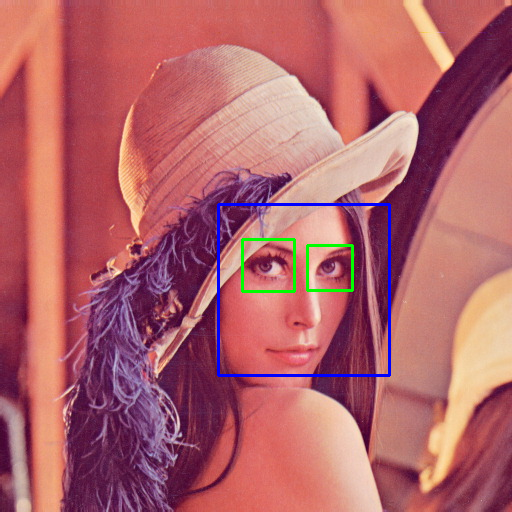

In [ ]:
detect_faces_and_eyes('lena.jpg')